In [159]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
!pip install openmeteo-requests requests-cache retry-requests


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [160]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "start_date": "2006-01-01",       # ← correct params for archive API
    "end_date": "2026-05-14",
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "precipitation",
        "wind_speed_10m",
        "wind_direction_10m",
        "surface_pressure",
        "cloud_cover",
        "weather_code"
    ]
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
hourly = response.Hourly()

df = pd.DataFrame({
    "datetime":             pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "temperature_2m":       hourly.Variables(0).ValuesAsNumpy(),
    "relative_humidity_2m": hourly.Variables(1).ValuesAsNumpy(),
    "dew_point_2m":         hourly.Variables(2).ValuesAsNumpy(),
    "apparent_temperature": hourly.Variables(3).ValuesAsNumpy(),
    "precipitation":        hourly.Variables(4).ValuesAsNumpy(),
    "wind_speed_10m":       hourly.Variables(5).ValuesAsNumpy(),
    "wind_direction_10m":   hourly.Variables(6).ValuesAsNumpy(),
    "surface_pressure":     hourly.Variables(7).ValuesAsNumpy(),
    "cloud_cover":          hourly.Variables(8).ValuesAsNumpy(),
    "weather_code":         hourly.Variables(9).ValuesAsNumpy(),
})

df['datetime'] = df['datetime'].dt.tz_convert('Asia/Kolkata')
df['weather_code'] = df['weather_code'].astype('Int64')

print(f"Saved {len(df)} rows")
print(df.isnull().sum())
print(df.describe())
print(df.head())

df.to_csv("delhi_weather_2006_2026.csv", index=False)
df.to_parquet("delhi_weather_2006_2026.parquet", index=False)
print("\nSaved to CSV and Parquet.")

Saved 178536 rows
datetime                0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
wind_speed_10m          0
wind_direction_10m      0
surface_pressure        0
cloud_cover             0
weather_code            0
dtype: int64
       temperature_2m  relative_humidity_2m   dew_point_2m  \
count   178536.000000         178536.000000  178536.000000   
mean        24.663837             60.757717      15.011031   
std          7.982857             23.286556       7.141021   
min          2.000000              4.429447     -10.902500   
25%         18.750000             42.252038       9.297500   
50%         26.000000             63.006165      13.900000   
75%         30.247499             80.555418      22.297501   
max         45.950001            100.000000      28.350000   

       apparent_temperature  precipitation  wind_speed_10m  \
count         178536.000000  178536.000000   178536.000000   


In [109]:
df.head()

,datetime,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,cloud_cover,weather_code
0,2006-01-01 05:30:00+05:30,10.0975,83.323654,7.397500,8.375674,0.0,7.200000,90.000000,993.000671,0.0,0
1,2006-01-01 06:30:00+05:30,9.7975,84.434692,7.297500,8.051302,0.0,7.200000,90.000000,993.071228,23.0,1
2,2006-01-01 07:30:00+05:30,9.5975,85.282738,7.247500,7.729404,0.0,7.952660,95.194344,993.150513,45.0,1
3,2006-01-01 08:30:00+05:30,11.7975,76.487175,7.797500,9.721215,0.0,10.308831,102.094742,994.030212,50.0,2
4,2006-01-01 09:30:00+05:30,15.8975,60.433933,8.247499,13.975740,0.0,10.028439,111.037582,994.487915,27.0,1


In [110]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(178536, 11)
datetime                datetime64[ns, Asia/Kolkata]
temperature_2m                               float32
relative_humidity_2m                         float32
dew_point_2m                                 float32
apparent_temperature                         float32
precipitation                                float32
wind_speed_10m                               float32
wind_direction_10m                           float32
surface_pressure                             float32
cloud_cover                                  float32
weather_code                                   Int64
dtype: object
datetime                0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
wind_speed_10m          0
wind_direction_10m      0
surface_pressure        0
cloud_cover             0
weather_code            0
dtype: int64
       temperature_2m  relative_humidity_2m   dew_point_2m  \
count   178536.000000        

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

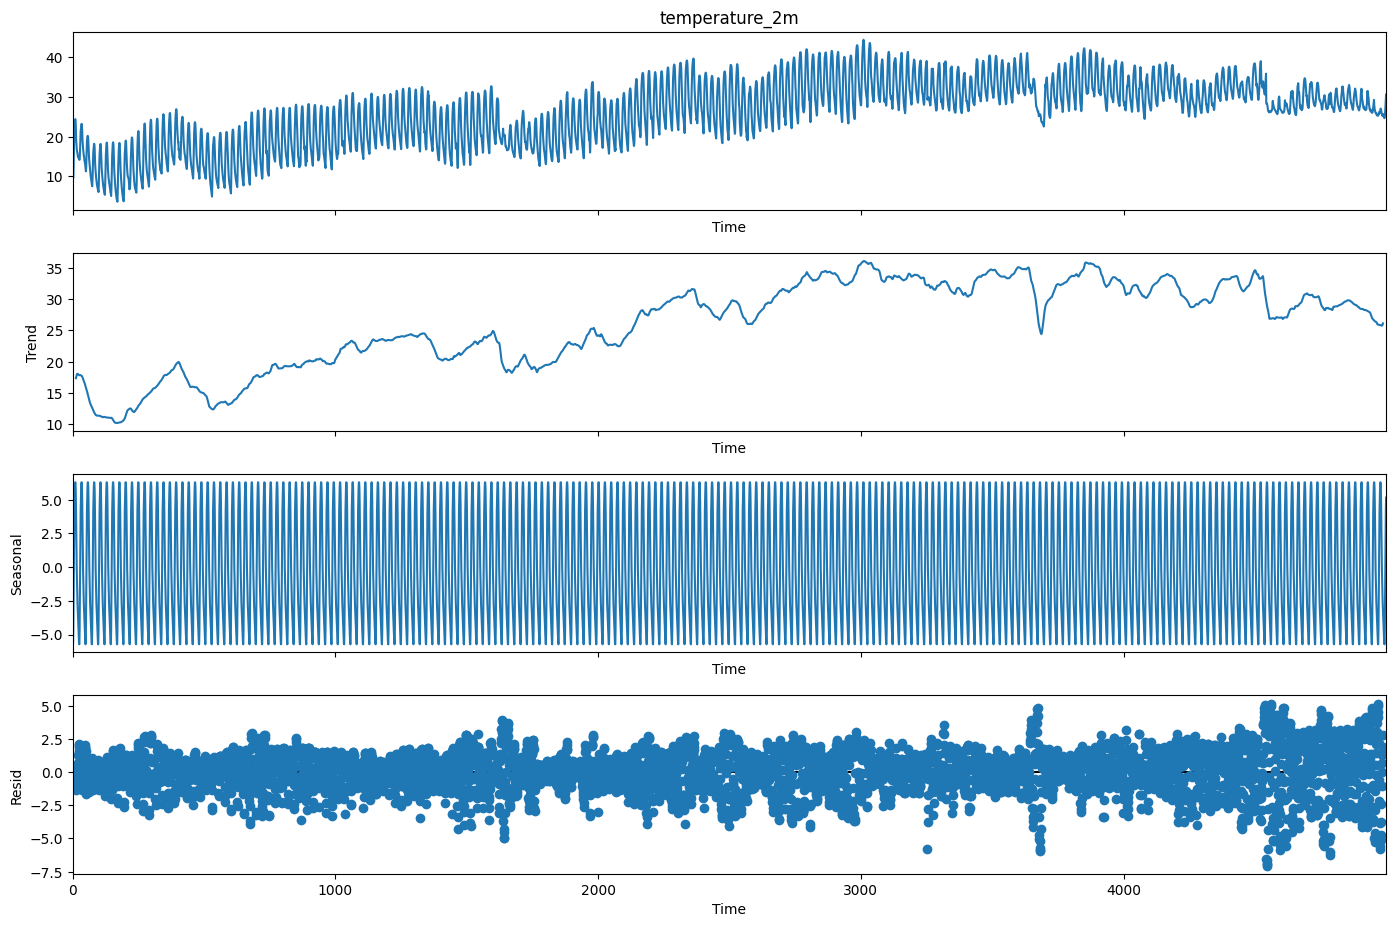

In [162]:

small = df.iloc[:5000]
results = seasonal_decompose(
    small['temperature_2m'],
    model='additive',
    period=24   # hourly data -> 24 hours/day cycle
)
fig = results.plot()
fig.set_size_inches(15, 10)
for ax in fig.axes:
    ax.set_xlabel("Time")
plt.show()

<Axes: >

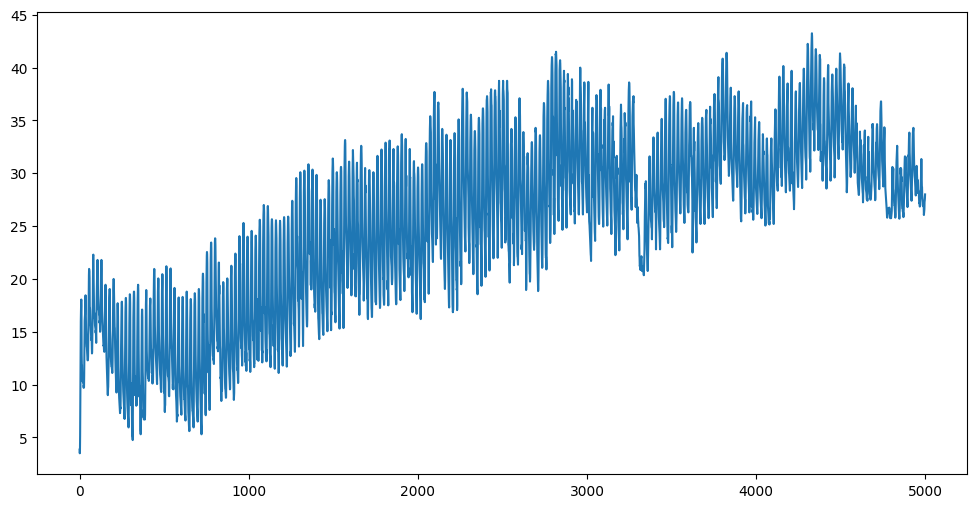

In [112]:
small['temperature_2m'].plot(figsize=(12,6))

In [163]:
df = pd.read_parquet("delhi_weather_2006_2026.parquet")
df = df.set_index("datetime")
df = df.sort_index()

## Just fixing the problem of CYCLICAL ENCODING
## as python won't underst
df['hour'] = df.index.hour
df['month'] = df.index.month
df['dayofyear'] = df.index.dayofyear
df['hour_sin']      = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']      = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']     = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']     = np.cos(2 * np.pi * df['month'] / 12)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
df['wind_dir_sin']  = np.sin(2*np.pi*df['wind_direction_10m']/360)
df['wind_dir_cos']  = np.cos(2*np.pi*df['wind_direction_10m']/360)

#---------------------------------------------

#Adding Lag Features
# ── Lag Features ──────────────────────────────────────────────────────────────
lag_cols = ['temperature_2m', 'apparent_temperature', 'surface_pressure',
            'relative_humidity_2m', 'wind_speed_10m', 'precipitation']

for col in lag_cols:
    df[f'{col}_lag1']  = df[col].shift(1)
    df[f'{col}_lag3']  = df[col].shift(3)
    df[f'{col}_lag6']  = df[col].shift(6)
    df[f'{col}_lag12']  = df[col].shift(12)
    df[f'{col}_lag24'] = df[col].shift(24)

# ── Rolling Features ──────────────────────────────────────────────────────────
roll_cols = ['temperature_2m', 'apparent_temperature', 'surface_pressure',
             'relative_humidity_2m', 'wind_speed_10m', 'precipitation']

for col in roll_cols:
    df[f'{col}_roll_3']  = df[col].shift(1).rolling(3).mean()
    df[f'{col}_roll_6']  = df[col].shift(1).rolling(6).mean()
    df[f'{col}_roll_24'] = df[col].shift(1).rolling(24).mean()
    df[f'{col}_roll_12_std'] = df[col].shift(1).rolling(12).std()
    df[f'{col}_roll_24_std'] = df[col].shift(1).rolling(24).std()
## Adding Temp change
df['temp_change_1h'] = df['temperature_2m'].diff(1)
df['temp_change_3h'] = df['temperature_2m'].diff(3)

## Adding Pressure Change
df['pressure_change_1h'] =  df['surface_pressure'].diff(1)
df['pressure_change_3h'] =  df['surface_pressure'].diff(3)

## As LSTM's like correlating features
df['feels_like_delta']    = df['apparent_temperature'] - df['temperature_2m']

## I also Wish to predict whether it is raining or not so here it is 
df['is_raining']          = (df['precipitation'] > 0.1).astype(int)


df = df.drop(columns=['hour', 'month', 'dayofyear', 'wind_direction_10m'], errors='ignore')
climatology = df.groupby([df.index.month, df.index.hour])['temperature_2m'].mean()
joblib.dump(climatology, 'climatology.pkl')
df['temp_anomaly'] = df['temperature_2m'] - df.groupby(
    [df.index.month, df.index.hour])['temperature_2m'].transform('mean')
df['temp_anomaly_lag1']  = df['temp_anomaly'].shift(1)
df['temp_anomaly_lag24'] = df['temp_anomaly'].shift(24)
df = df.dropna()
df= df.drop(columns=['weather_code'])
print(df.shape)
print(f"Features: {len(df.columns)}")

(178512, 85)
Features: 85


In [165]:
for i in range(1, 7):
    df[f'target_temp_{i}h']     = df['temperature_2m'].shift(-i)
    df[f'target_apparent_{i}h'] = df['apparent_temperature'].shift(-i)
    df[f'target_rain_{i}h']     = df['is_raining'].shift(-i)
df = df.dropna()
target_cols = [f'target_temp_{i}h'     for i in range(1, 7)] + \
              [f'target_apparent_{i}h' for i in range(1, 7)] + \
              [f'target_rain_{i}h'     for i in range(1, 7)]

X = df.drop(columns=target_cols + ['is_raining'], errors='ignore')
y_temp     = df[[f'target_temp_{i}h'     for i in range(1, 7)]].values  
y_apparent = df[[f'target_apparent_{i}h' for i in range(1, 7)]].values  
y_rain     = df[[f'target_rain_{i}h'     for i in range(1, 7)]].values 

from sklearn.preprocessing import MinMaxScaler
## Train - Test split can't do randomly ofc
n= len(X)
end = int(n*0.8)

X_train = X.iloc[:end]
X_test= X.iloc[end:]

y_temp_train = y_temp[:end]
y_apparent_train = y_apparent[:end]
y_rain_train = y_rain[:end]
y_temp_test = y_temp[end:]
y_apparent_test = y_apparent[end:]
y_rain_test = y_rain[end:]

## scaling the data only for regressive part obviously
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y_temp = MinMaxScaler()
y_temp_train_scaled = scaler_y_temp.fit_transform(y_temp_train)
y_temp_test_scaled = scaler_y_temp.transform(y_temp_test)

scaler_y_apparent = MinMaxScaler()
y_apparent_train_scaled = scaler_y_apparent.fit_transform(y_apparent_train)
y_apparent_test_scaled = scaler_y_apparent.transform(y_apparent_test)

y_train = np.hstack([y_temp_train_scaled , y_apparent_train_scaled , y_rain_train])
y_test = np.hstack([y_temp_test_scaled , y_apparent_test_scaled , y_rain_test])

import joblib

joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y_temp, "scaler_y_temp.pkl")
joblib.dump(scaler_y_apparent, "scaler_y_apparent.pkl")
## FINAL 
# X_train_scaled , X_test_scaled
#y_train , y_test
print(X_train_scaled.shape)
print(y_train.shape)



(142800, 84)
(142800, 18)


In [166]:
## Setting up data for putting in model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
window = 24
batch_size = 64
train_gen = TimeseriesGenerator(X_train_scaled,y_train ,length = window,batch_size =batch_size )
test_gen = TimeseriesGenerator(X_test_scaled,y_test ,length = window,batch_size = batch_size)

In [167]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout ,Conv1D ,MaxPooling1D, LayerNormalization

inputs = Input(shape=(window,X_train_scaled.shape[1]))
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = LayerNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
x = LayerNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=256, kernel_size=3, activation='relu', padding='same')(x)
x = LayerNormalization()(x)
x = LSTM(256,return_sequences=True)(x)
x= Dropout(0.2)(x)
x = LSTM(128,return_sequences=False)(x)
x = Dropout(0.2)(x)
x = Dense(32,activation='relu')(x)
temp_out = Dense(6,activation = 'linear', name='temp')(x)
apparent_out = Dense(6,activation = 'linear', name='apparent')(x)
rain_out = Dense(6,activation = 'sigmoid', name='rain')(x)
model = Model(inputs=inputs, outputs=[temp_out, apparent_out, rain_out])
model.compile(optimizer='adam' ,
              loss ={
                  'temp' : 'mse',
                  'apparent' : 'mse',
                  'rain' : 'binary_crossentropy'
              },
              metrics={
                  'temp' : 'mae',
                  'apparent' : 'mae',
                  'rain' : 'accuracy'
              }
             )
model.summary()


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 24, 84)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 24, 64)    │     16,192 │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ conv1d_20[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 12, 64)    │          0 │ layer_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 12, 128)   │     24,704 │ max_pooling1d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ conv1d_21[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_13    │ (None, 6, 128)    │          0 │ layer_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 6, 256)    │     98,560 │ max_pooling1d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 256)    │        512 │ conv1d_22[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_32 (LSTM)      │ (None, 6, 256)    │    525,312 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 6, 256)    │          0 │ lstm_32[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_33 (LSTM)      │ (None, 128)       │    197,120 │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 128)       │          0 │ lstm_33[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │      4,128 │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temp (Dense)        │ (None, 6)         │        198 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apparent (Dense)    │ (None, 6)         │        198 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rain (Dense)        │ (None, 6)         │        198 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 867,506 (3.31 MB)

 Trainable params: 867,506 (3.31 MB)

 Non-trainable params: 0 (0.00 B)

In [168]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.keras', save_best_only=True),
    ModelCheckpoint(
        'best_weights.weights.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
    )
]


In [169]:
def generate_batches(gen):
    while(True):
        for i in range(len(gen)):
            X_batch, y_batch = gen[i]
            yield X_batch ,{
                'temp':     y_batch[:, 0:6],  
                'apparent': y_batch[:, 6:12],   
                'rain':  y_batch[:, 12:18]
            }
train_data = generate_batches(train_gen)
test_data  = generate_batches(test_gen)
print(window)                 
print(train_gen[0][0].shape)
history = model.fit(
    train_data,
    steps_per_epoch=len(train_gen),
    validation_data=test_data,
    validation_steps=len(test_gen),
    epochs=30,
    verbose =1,
    callbacks=callbacks
)


24
(64, 24, 84)
Epoch 1/30
2231/2231 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - apparent_loss: 0.0272 - apparent_mae: 0.1292 - loss: 0.3399 - rain_accuracy: 0.0460 - rain_loss: 0.2820 - temp_loss: 0.0307 - temp_mae: 0.1365 - val_apparent_loss: 0.0403 - val_apparent_mae: 0.1626 - val_loss: 0.3229 - val_rain_accuracy: 0.0182 - val_rain_loss: 0.2301 - val_temp_loss: 0.0525 - val_temp_mae: 0.1845 - learning_rate: 0.0010
Epoch 2/30
2231/2231 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - apparent_loss: 0.0236 - apparent_mae: 0.1206 - loss: 0.3170 - rain_accuracy: 0.0696 - rain_loss: 0.2676 - temp_loss: 0.0257 - temp_mae: 0.1257 - val_apparent_loss: 0.0463 - val_apparent_mae: 0.1853 - val_loss: 0.3170 - val_rain_accuracy: 0.0207 - val_rain_loss: 0.2303 - val_temp_loss: 0.0404 - val_temp_mae: 0.1684 - learning_rate: 0.0010
Epoch 3/30
2231/2231 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - apparent_loss: 0.0251 - apparent_mae: 0.1250 - loss: 0.3195 - rain_accuracy: 0.1456 - rain_loss: 0.2669 - temp_loss: 0.0274 - temp

In [170]:

print(history.history['val_loss'])
print(history.history['val_temp_mae'])
print(history.history['val_apparent_mae'])
print(history.history['val_rain_accuracy'])

[0.3228580355644226, 0.3170316517353058, 0.3299839198589325, 0.341705322265625, 0.3364197015762329, 0.3163421154022217, 0.31472328305244446, 0.31338655948638916, 0.31054502725601196, 0.31000465154647827, 0.30985426902770996, 0.30999675393104553, 0.2208801954984665, 0.1923137605190277, 0.1881427764892578, 0.17610596120357513, 0.16920629143714905, 0.16927781701087952, 0.1694639027118683, 0.16880278289318085, 0.16726505756378174, 0.16703592240810394, 0.16583755612373352, 0.16508011519908905, 0.16546650230884552, 0.1655118763446808, 0.16601084172725677, 0.16387148201465607, 0.16321004927158356, 0.16411995887756348]
[0.18446964025497437, 0.1684291809797287, 0.1877231001853943, 0.19349324703216553, 0.18695098161697388, 0.17019852995872498, 0.16818584501743317, 0.165695920586586, 0.16325223445892334, 0.16281114518642426, 0.16247625648975372, 0.16252970695495605, 0.07721912115812302, 0.08209750801324844, 0.08691158890724182, 0.0633845403790474, 0.052756354212760925, 0.05597219988703728, 0.0579

In [171]:
y_pred = model.predict(test_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [172]:
temp_pred     = y_pred[0]  
apparent_pred = y_pred[1] 
rain_pred     = y_pred[2]
temp_pred_real     = scaler_y_temp.inverse_transform(temp_pred)
apparent_pred_real = scaler_y_apparent.inverse_transform(apparent_pred)
rain_pred_binary = (rain_pred > 0.5).astype(int)
y_actual = y_test[window:]  
temp_actual     = scaler_y_temp.inverse_transform(y_actual[:, 0:6])
apparent_actual = scaler_y_apparent.inverse_transform(y_actual[:, 6:12])
rain_actual     = y_actual[:, 12:18]
from sklearn.metrics import mean_absolute_error, accuracy_score

print(f"Temperature MAE     : {mean_absolute_error(temp_actual, temp_pred_real):.2f} °C")
print(f"Apparent Temp MAE   : {mean_absolute_error(apparent_actual, apparent_pred_real):.2f} °C")
print(f"Rain Accuracy       : {accuracy_score(rain_actual, rain_pred_binary)*100:.2f} %")

Temperature MAE     : 1.59 °C
Apparent Temp MAE   : 2.03 °C
Rain Accuracy       : 84.40 %


In [174]:
import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
from retry_requests import retry
import joblib
from tensorflow.keras.models import load_model
from datetime import datetime, timezone


model     = load_model('best_model.keras')
scaler_X        = joblib.load('scaler_X.pkl')
scaler_temp     = joblib.load('scaler_y_temp.pkl')
scaler_apparent = joblib.load('scaler_y_apparent.pkl')


def fetch_realtime(hours):
    cache_session = requests_cache.CachedSession('.cache_realtime', expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo     = openmeteo_requests.Client(session=retry_session)

    url    = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude":  28.6139,
        "longitude": 77.2090,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "dew_point_2m",
            "apparent_temperature",
            "precipitation",
            "wind_speed_10m",
            "wind_direction_10m",
            "surface_pressure",
            "cloud_cover"
        ],
        "past_hours": hours,
        "forecast_hours": 1,
        "timezone": "Asia/Kolkata"
    }

    responses = openmeteo.weather_api(url, params=params)
    response  = responses[0]
    hourly    = response.Hourly()

    df = pd.DataFrame({
        "datetime":             pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        ),
        "temperature_2m":       hourly.Variables(0).ValuesAsNumpy(),
        "relative_humidity_2m": hourly.Variables(1).ValuesAsNumpy(),
        "dew_point_2m":         hourly.Variables(2).ValuesAsNumpy(),
        "apparent_temperature": hourly.Variables(3).ValuesAsNumpy(),
        "precipitation":        hourly.Variables(4).ValuesAsNumpy(),
        "wind_speed_10m":       hourly.Variables(5).ValuesAsNumpy(),
        "wind_direction_10m":   hourly.Variables(6).ValuesAsNumpy(),
        "surface_pressure":     hourly.Variables(7).ValuesAsNumpy(),
        "cloud_cover":          hourly.Variables(8).ValuesAsNumpy(),
    })

    df['datetime'] = df['datetime'].dt.tz_convert('Asia/Kolkata')
    df = df.set_index('datetime')
    df = df.sort_index()
    return df



In [196]:
def engineer_features(df):
        ## Just fixing the problem of CYCLICAL ENCODING
    ## as python won't underst
    df['hour'] = df.index.hour
    df['month'] = df.index.month
    df['dayofyear'] = df.index.dayofyear
    df['hour_sin']      = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']      = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']     = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']     = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
    df['wind_dir_sin']  = np.sin(2*np.pi*df['wind_direction_10m']/360)
    df['wind_dir_cos']  = np.cos(2*np.pi*df['wind_direction_10m']/360)
    
    #---------------------------------------------
    lag_cols = ['temperature_2m', 'apparent_temperature', 'surface_pressure',
            'relative_humidity_2m', 'wind_speed_10m', 'precipitation']   
    for col in lag_cols:
        df[f'{col}_lag1']  = df[col].shift(1)
        df[f'{col}_lag3']  = df[col].shift(3)
        df[f'{col}_lag6']  = df[col].shift(6)
        df[f'{col}_lag12']  = df[col].shift(12)
        df[f'{col}_lag24'] = df[col].shift(24)


    roll_cols = ['temperature_2m', 'apparent_temperature', 'surface_pressure',
             'relative_humidity_2m', 'wind_speed_10m', 'precipitation']

    for col in roll_cols:
        df[f'{col}_roll_3']  = df[col].shift(1).rolling(3).mean()
        df[f'{col}_roll_6']  = df[col].shift(1).rolling(6).mean()
        df[f'{col}_roll_24'] = df[col].shift(1).rolling(24).mean()
        df[f'{col}_roll_12_std'] = df[col].shift(1).rolling(12).std()
        df[f'{col}_roll_24_std'] = df[col].shift(1).rolling(24).std()
        
    ## Adding Temp change
    df['temp_change_1h'] = df['temperature_2m'].diff(1)
    df['temp_change_3h'] = df['temperature_2m'].diff(3)
    
    ## Adding Pressure Change
    df['pressure_change_1h'] =  df['surface_pressure'].diff(1)
    df['pressure_change_3h'] =  df['surface_pressure'].diff(3)
    
    ## As LSTM's like correlating features
    df['feels_like_delta']    = df['apparent_temperature'] - df['temperature_2m']
    
    ## I also Wish to predict whether it is raining or not so here it is 
    df['is_raining']          = (df['precipitation'] > 0.1).astype(int)
    
    df = df.drop(columns=['hour', 'month', 'dayofyear', 'wind_direction_10m'], errors='ignore')
    climatology = joblib.load('climatology.pkl')
    df['temp_anomaly'] = df.apply(
        lambda r:
        r['temperature_2m']
        - climatology.loc[(r.name.month, r.name.hour)],
        axis=1)
    df['temp_anomaly_lag1']  = df['temp_anomaly'].shift(1)
    df['temp_anomaly_lag24'] = df['temp_anomaly'].shift(24)

    df = df.dropna()
    return df

In [197]:
def predict_next_6_hours():
    raw_data    = fetch_realtime(48)
    featured_df = engineer_features(raw_data)
    featured_df = featured_df.drop(columns=['is_raining', 'weather_code'], errors='ignore')

    window        = featured_df.tail(24)
    window_scaled = scaler_X.transform(window)
    window_scaled = window_scaled.reshape(1, 24, -1)

    y_pred = model.predict(window_scaled, verbose=0)

    temp_preds     = scaler_temp.inverse_transform(y_pred[0])[0]      # 6 values
    apparent_preds = scaler_apparent.inverse_transform(y_pred[1])[0]  # 6 values
    rain_probs     = y_pred[2][0]                                      # 6 values

    base_time = featured_df.index[-1]

    print(f"\n{'='*55}")
    print(f"  6 Hour Forecast from {base_time.strftime('%Y-%m-%d %H:%M IST')}")
    print(f"{'='*55}")
    print(f"  {'Hour':<6} {'Time':<10} {'Temp':>6} {'Feels':>6} {'Rain%':>6} {'Rain':>6}")
    print(f"  {'-'*50}")

    results = []
    for i in range(6):
        forecast_time = base_time + pd.Timedelta(hours=i+1)
        print(f"  +{i+1}h    {forecast_time.strftime('%H:%M'):<10} "
              f"{temp_preds[i]:>5.1f}° "
              f"{apparent_preds[i]:>5.1f}° "
              f"{rain_probs[i]*100:>5.1f}% "
              f"{'🌧' if rain_probs[i] > 0.5 else '☀️'}")
        results.append({
            'datetime':    forecast_time,
            'temperature': round(float(temp_preds[i]), 1),
            'apparent':    round(float(apparent_preds[i]), 1),
            'rain_prob':   round(float(rain_probs[i] * 100), 1),
            'is_raining':  bool(rain_probs[i] > 0.5)
        })

    print(f"{'='*55}\n")
    return results
result = predict_next_6_hours()


  6 Hour Forecast from 2026-05-20 23:00 IST
  Hour   Time         Temp  Feels  Rain%   Rain
  --------------------------------------------------
  +1h    00:00       32.7°  32.2°   0.0% ☀️
  +2h    01:00       32.8°  31.7°   0.0% ☀️
  +3h    02:00       31.6°  31.7°   0.0% ☀️
  +4h    03:00       31.5°  31.5°   0.0% ☀️
  +5h    04:00       30.6°  30.3°   0.0% ☀️
  +6h    05:00       30.1°  29.7°   0.0% ☀️



In [198]:
raw_data    = fetch_realtime(48)
featured_df = engineer_features(raw_data)
featured_df = featured_df.drop(columns=['is_raining', 'weather_code'], errors='ignore')
window      = featured_df.tail(24)
print(window[['temperature_2m', 'apparent_temperature']].tail(5))
print(f"Last timestamp: {window.index[-1]}")
print(f"Predicting for: {window.index[-1] + pd.Timedelta(hours=1)}")


                           temperature_2m  apparent_temperature
datetime                                                       
2026-05-20 19:00:00+05:30       39.700001             38.560314
2026-05-20 20:00:00+05:30       39.099998             38.204784
2026-05-20 21:00:00+05:30       38.349998             37.615284
2026-05-20 22:00:00+05:30       37.000000             36.180923
2026-05-20 23:00:00+05:30       35.150002             34.606770
Last timestamp: 2026-05-20 23:00:00+05:30
Predicting for: 2026-05-21 00:00:00+05:30


In [200]:
raw_data    = fetch_realtime(48)
featured_df = engineer_features(raw_data)
featured_df = featured_df.drop(columns=['is_raining', 'weather_code'], errors='ignore')
window      = featured_df.tail(24)
print(window[['temperature_2m', 'apparent_temperature']].tail(5))
print(f"Last timestamp: {window.index[-1]}")
print(f"Predicting for: {window.index[-1] + pd.Timedelta(hours=1)}")

                           temperature_2m  apparent_temperature
datetime                                                       
2026-05-20 19:00:00+05:30       39.700001             38.560314
2026-05-20 20:00:00+05:30       39.099998             38.204784
2026-05-20 21:00:00+05:30       38.349998             37.615284
2026-05-20 22:00:00+05:30       37.000000             36.180923
2026-05-20 23:00:00+05:30       35.150002             34.606770
Last timestamp: 2026-05-20 23:00:00+05:30
Predicting for: 2026-05-21 00:00:00+05:30


In [206]:
def finetune_on_recent(model, hours):
    raw = fetch_realtime(hours=hours)
    featured = engineer_features(raw)
    featured = featured.drop(columns=['is_raining'], errors='ignore')

    for i in range(1, 7):
        featured[f'target_temp_{i}h']     = featured['temperature_2m'].shift(-i)
        featured[f'target_apparent_{i}h'] = featured['apparent_temperature'].shift(-i)
        featured[f'target_rain_{i}h']     = featured['is_raining'] if 'is_raining' in featured.columns else (featured['precipitation'] > 0.1).astype(int).shift(-i)
    
    featured = featured.dropna()

    target_cols = [f'target_temp_{i}h'     for i in range(1, 7)] + \
                  [f'target_apparent_{i}h' for i in range(1, 7)] + \
                  [f'target_rain_{i}h'     for i in range(1, 7)]

    X_ft = featured.drop(columns=target_cols, errors='ignore')
    y_temp_ft     = featured[[f'target_temp_{i}h'     for i in range(1, 7)]].values
    y_apparent_ft = featured[[f'target_apparent_{i}h' for i in range(1, 7)]].values
    y_rain_ft     = featured[[f'target_rain_{i}h'     for i in range(1, 7)]].values

    X_ft_scaled        = scaler_X.transform(X_ft)
    y_temp_ft_scaled     = scaler_temp.transform(y_temp_ft)
    y_apparent_ft_scaled = scaler_apparent.transform(y_apparent_ft)

    y_ft = np.hstack([y_temp_ft_scaled, y_apparent_ft_scaled, y_rain_ft])


    for layer in model.layers:
        if any(x in layer.name for x in ['conv1d', 'max_pooling', 'layer_normalization']):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss={'temp': 'mse', 'apparent': 'mse', 'rain': 'binary_crossentropy'},
        metrics={'temp': 'mae', 'apparent': 'mae', 'rain': 'accuracy'}
    )

    gen = TimeseriesGenerator(X_ft_scaled, y_ft, length=24, batch_size=32)
    ft_data = generate_batches(gen)

    model.fit(ft_data, steps_per_epoch=len(gen), epochs=5, verbose=1)
    model.save('best_model.keras')
    print("Fine-tuning done.")

In [207]:
import tensorflow as tf
finetune_on_recent(model, hours=720)
result = predict_next_6_hours()

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - apparent_loss: 0.0029 - apparent_mae: 0.0421 - loss: 0.0826 - rain_accuracy: 0.3616 - rain_loss: 0.0772 - temp_loss: 0.0024 - temp_mae: 0.0381
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - apparent_loss: 0.0025 - apparent_mae: 0.0385 - loss: 0.0823 - rain_accuracy: 0.3619 - rain_loss: 0.0776 - temp_loss: 0.0021 - temp_mae: 0.0354
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - apparent_loss: 0.0024 - apparent_mae: 0.0382 - loss: 0.0815 - rain_accuracy: 0.3538 - rain_loss: 0.0768 - temp_loss: 0.0022 - temp_mae: 0.0364
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - apparent_loss: 0.0023 - apparent_mae: 0.0367 - loss: 0.0806 - rain_accuracy: 0.3617 - rain_loss: 0.0761 - temp_loss: 0.0021 - temp_mae: 0.0357
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - apparent_loss: 0.0023 - apparent_mae: 0.0371 - loss: 0.0804 - rain_accuracy: 0.3358 - rain_loss: 0.0760 - temp_loss: 0.0020 - temp_mae: 0.0347
Fine-tuning done.

  6 Ho